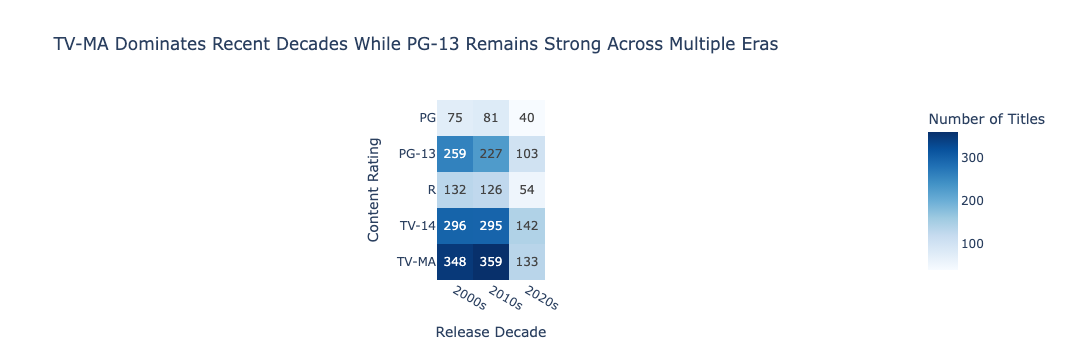

In [2]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("netflix_catalogue.csv")

df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
filtered_df = df[df['rating'].isin(ratings)]

heatmap_data = (
    filtered_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

pivot_table = heatmap_data.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

pivot_table = pivot_table.reindex(
    sorted(pivot_table.columns, key=lambda x: int(x[:-1])),
    axis=1
)

fig = px.imshow(
    pivot_table,
    text_auto=True,
    color_continuous_scale='Blues',
    labels={
        'x': 'Release Decade',
        'y': 'Content Rating',
        'color': 'Number of Titles'
    },
    title='TV-MA Dominates Recent Decades While PG-13 Remains Strong Across Multiple Eras'
)

fig.show()

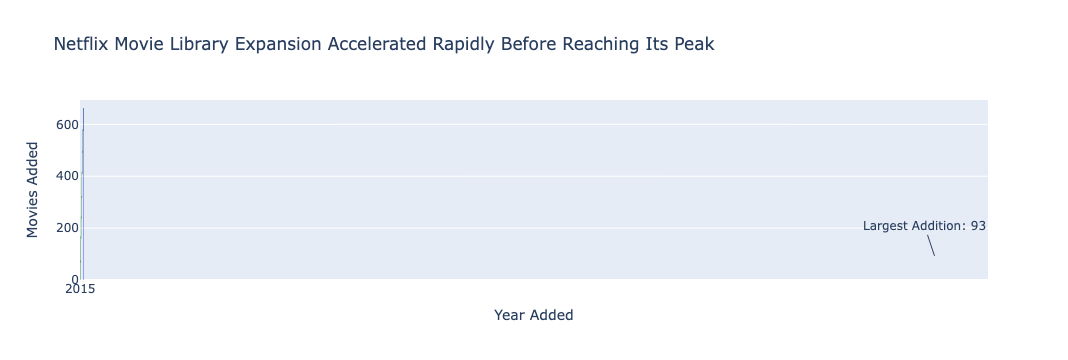

In [5]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv("netflix_catalogue.csv")

movie_counts = (
    df[df['type'] == 'Movie']
    .groupby('added_year')
    .size()
    .reset_index(name='count')
)

movie_counts = movie_counts[
    (movie_counts['added_year'] >= 2015) &
    (movie_counts['added_year'] <= 2022)
].sort_values('added_year')

max_year = movie_counts.loc[movie_counts['count'].idxmax(), 'added_year']
max_count = movie_counts['count'].max()

fig = go.Figure(go.Waterfall(
    measure=['relative'] * len(movie_counts) + ['total'],
    x=list(movie_counts['added_year'].astype(str)) + ['Total'],
    y=list(movie_counts['count']) + [0],
    increasing={'marker': {'color': 'green'}},
    totals={'marker': {'color': 'blue'}}
))

fig.add_annotation(
    x=str(max_year),
    y=max_count,
    text=f'Largest Addition: {max_count}',
    showarrow=True
)

fig.update_layout(
    title='Netflix Movie Library Expansion Accelerated Rapidly Before Reaching Its Peak',
    xaxis_title='Year Added',
    yaxis_title='Movies Added'
)

fig.show()